# Notebook 2: Gaussian Mixture Model (GMM) trên đặc trưng RFM

## Đầu vào
- File `data/rfm_customers.csv` từ bước tiền xử lý.
- Ma trận đặc trưng: **`R_z`, `F_z`, `M_z`** (đã log1p cho F/M rồi chuẩn hóa z-score) — cùng không gian với bước phân cụm sau.

## Mục tiêu
1. Chọn số thành phần hỗn hợp \(K\) bằng **AIC / BIC** (thử nhiều giá trị \(K\)).
2. Huấn luyện **GMM** cuối cùng, gán **xác suất / nhãn thành phần** cho từng khách.
3. Lưu mô hình và bảng kết quả để notebook phân cụm / pipeline sau dùng lại.

## Ghi chú
- Số thành phần GMM **không bắt buộc** trùng số cụm K-means trong bước marketing; có thể chọn \(K\) theo BIC rồi ở bước sau dùng số cụm khác (elbow) — trong notebook sẽ ghi rõ giá trị chọn được.
- `covariance_type='full'`: hiệp phương sai đầy đủ (3 chiều, dữ liệu vừa phải). Nếu cần tăng tốc có thể đổi sang `'diag'`.
- **K_CAP** (trong code): giới hạn tối đa K khi chọn BIC — tránh BIC chọn K quá lớn, khó diễn giải; có thể đặt `None` để không giới hạn.

In [ ]:
from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "rfm_customers.csv"
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = ROOT / "data"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = ["R_z", "F_z", "M_z"]
RANDOM_STATE = 42

# GMM: số lần khởi tạo EM, ổn định số học
N_INIT = 10
MAX_ITER = 300
REG_COVAR = 1e-3
COVARIANCE_TYPE = "full"

# Thử K từ K_MIN đến K_MAX (số thành phần Gaussian)
K_MIN, K_MAX = 2, 12

K_CAP = 8

In [ ]:
rfm = pd.read_csv(DATA_PATH)

X = rfm[FEATURE_COLS].to_numpy(dtype=float)
print("Shape X:", X.shape)
print(rfm[FEATURE_COLS].describe())

Shape X: (5878, 3)
                R_z           F_z           M_z
count  5.878000e+03  5.878000e+03  5.878000e+03
mean  -5.197914e-17  2.435767e-16 -4.400095e-16
std    1.000085e+00  1.000085e+00  1.000085e+00
min   -9.570564e-01 -1.058146e+00 -3.936481e+00
25%   -8.376226e-01 -1.058146e+00 -7.056734e-01
50%   -5.032078e-01 -2.017514e-01 -2.467978e-02
75%    8.535607e-01  6.546432e-01  6.540289e-01
max    2.568631e+00  5.484918e+00  4.671413e+00


In [3]:
rows = []
for k in range(K_MIN, K_MAX + 1):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=COVARIANCE_TYPE,
        random_state=RANDOM_STATE,
        n_init=N_INIT,
        max_iter=MAX_ITER,
        reg_covar=REG_COVAR,
    )
    gmm.fit(X)
    rows.append(
        {
            "n_components": k,
            "aic": gmm.aic(X),
            "bic": gmm.bic(X),
            "log_likelihood": gmm.score(X) * len(X),
        }
    )

crit = pd.DataFrame(rows)
crit_path = OUT_DIR / "gmm_model_selection.csv"
crit.to_csv(crit_path, index=False)
print("Đã lưu:", crit_path.resolve())
crit

Đã lưu: /Users/kotori/GMS_AFKMC2/data/gmm_model_selection.csv


,n_components,aic,bic,log_likelihood
0,2,33767.060234,33893.960699,-16864.530117
1,3,32925.329599,33119.019783,-16433.664800
2,4,26380.781713,26641.261615,-13151.390857
3,5,25997.310997,26324.580617,-12949.655498
4,6,23463.201764,23857.261103,-11672.600882
5,7,23044.971649,23505.820707,-11453.485825
6,8,22400.325130,22927.963906,-11121.162565
7,9,21711.249145,22305.677639,-10766.624572
8,10,21038.531810,21699.750023,-10420.265905
9,11,21454.873292,22182.881224,-10618.436646


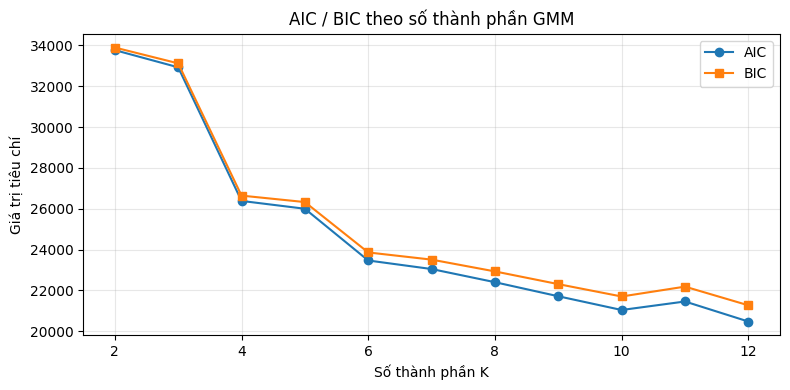

K theo BIC (sau giới hạn K_CAP): 8 | K_CAP = 8
Số thành phần GMM dùng để fit cuối: 8


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(crit["n_components"], crit["aic"], marker="o", label="AIC")
ax.plot(crit["n_components"], crit["bic"], marker="s", label="BIC")
ax.set_xlabel("Số thành phần K")
ax.set_ylabel("Giá trị tiêu chí")
ax.legend()
ax.grid(True, alpha=0.3)
plt.title("AIC / BIC theo số thành phần GMM")
plt.tight_layout()
plt.show()

# Chọn K theo BIC (có thể giới hạn bởi K_CAP)
if K_CAP is None:
    best_k = int(crit.loc[crit["bic"].idxmin(), "n_components"])
else:
    sub = crit[crit["n_components"] <= K_CAP]
    best_k = int(sub.loc[sub["bic"].idxmin(), "n_components"])
print("K theo BIC (sau giới hạn K_CAP):", best_k, "| K_CAP =", K_CAP)

# Tùy chọn: ép K cố định (ví dụ 4 cụm marketing) — đặt USE_FIXED_K = True và sửa FIXED_K
USE_FIXED_K = False
FIXED_K = 4

N_COMPONENTS = FIXED_K if USE_FIXED_K else best_k
print("Số thành phần GMM dùng để fit cuối:", N_COMPONENTS)

In [5]:
gmm_final = GaussianMixture(
    n_components=N_COMPONENTS,
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    reg_covar=REG_COVAR,
)
gmm_final.fit(X)

proba = gmm_final.predict_proba(X)
labels = gmm_final.predict(X)
rfm_out = rfm.copy()
rfm_out["gmm_component"] = labels
rfm_out["gmm_max_proba"] = proba.max(axis=1)

for j in range(N_COMPONENTS):
    rfm_out[f"gmm_p_{j}"] = proba[:, j]

model_path = MODEL_DIR / "gmm_rfm.joblib"
joblib.dump(
    {
        "gmm": gmm_final,
        "feature_cols": FEATURE_COLS,
        "n_components": N_COMPONENTS,
        "covariance_type": COVARIANCE_TYPE,
        "bic_used_for_selection": not USE_FIXED_K,
        "best_k_by_bic": best_k,
    },
    model_path,
)
print("Đã lưu mô hình:", model_path.resolve())

csv_path = OUT_DIR / "rfm_with_gmm.csv"
rfm_out.to_csv(csv_path, index=False)
print("Đã lưu bảng:", csv_path.resolve())
rfm_out.head()

Đã lưu mô hình: /Users/kotori/GMS_AFKMC2/models/gmm_rfm.joblib
Đã lưu bảng: /Users/kotori/GMS_AFKMC2/data/rfm_with_gmm.csv


,customer_id,R,F,M,F_log1p,M_log1p,R_z,F_z,M_z,gmm_component,gmm_max_proba,gmm_p_0,gmm_p_1,gmm_p_2,gmm_p_3,gmm_p_4,gmm_p_5,gmm_p_6,gmm_p_7
0,12346.0,325,12,77556.46,2.564949,11.258774,0.595584,1.254496,3.186625,6,0.999999,4.632299e-26,4.280345e-119,0.000000e+00,0.000000e+00,5.595045e-07,1.234727e-17,0.999999,0.000000e+00
1,12347.0,1,8,5633.32,2.197225,8.636632,-0.952279,0.800166,1.297127,1,0.877553,1.527476e-11,8.775532e-01,0.000000e+00,0.000000e+00,1.437742e-02,1.046272e-01,0.003442,0.000000e+00
2,12348.0,74,5,2019.40,1.791759,7.611051,-0.603532,0.299207,0.558100,5,0.863552,1.097811e-02,2.943322e-04,0.000000e+00,0.000000e+00,1.233980e-01,8.635517e-01,0.001778,2.262334e-160
3,12349.0,18,4,4428.69,1.609438,8.396085,-0.871064,0.073946,1.123790,1,0.663384,1.460405e-01,6.633837e-01,3.904817e-280,3.096199e-281,1.888781e-02,1.645557e-01,0.007132,4.434242e-88
4,12350.0,309,1,334.40,0.693147,5.815324,0.519146,-1.058146,-0.735888,3,0.999456,5.650789e-19,1.998026e-102,2.168484e-15,9.994559e-01,4.462775e-04,7.718468e-20,0.000098,2.905215e-55


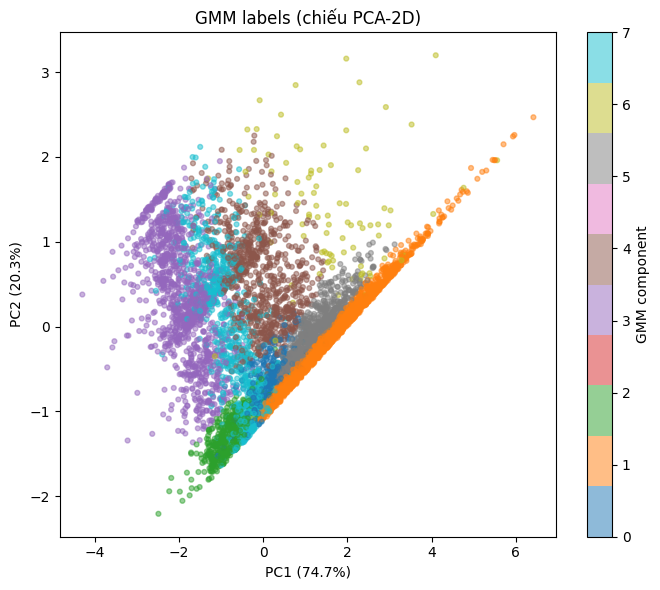

In [6]:
# PCA-2D để trực quan hóa (chỉ để vẽ, không thay đổi GMM)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X2[:, 0], X2[:, 1], c=labels, cmap="tab10", alpha=0.5, s=12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter, ax=ax, label="GMM component")
plt.title("GMM labels (chiếu PCA-2D)")
plt.tight_layout()
plt.show()